# 02 - Fleet SQL Analysis

**Project:** Predictive Maintenance - Maintenance Required Prediction
**Goal:** Analyze the normalized fleet dataset using SQL to answer key business questions
about maintenance rates, costs, route performance, and risk segmentation.

> **Note on SQL approach:** Queries are executed via Python's built-in `sqlite3` library
> so that results and charts appear inline in the notebook. The same queries as standalone
> `.sql` files are available in the `sql/` folder for use in any SQL client (DBeaver,
> DataGrip, pgAdmin, etc.).

**Database schema (8 tables):**

| Table | Description |
|-------|-------------|
| `vehicle` | Main fact table (92,000 rows) |
| `model` | Vehicle make and model lookup |
| `vehicle_type` | Truck / Van lookup |
| `route` | Route type lookup (Highway / Rural / Urban) |
| `maintenance_type` | Type of maintenance lookup |
| `brake` | Brake condition lookup |
| `weather` | Weather conditions lookup |
| `road` | Road conditions lookup |

---

## 1. Setup and Database Loading

In [1]:
# Import required libraries for SQL analysis and visualization.
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", palette="muted")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load all CSV files and insert them into an in-memory SQLite database.
RAW = "../data/raw/"

tables = {
    "vehicle":          pd.read_csv(RAW + "vehicle.csv"),
    "model":            pd.read_csv(RAW + "model.csv"),
    "vehicle_type":     pd.read_csv(RAW + "vehicle_type.csv"),
    "route":            pd.read_csv(RAW + "route.csv"),
    "maintenance_type": pd.read_csv(RAW + "maintenance_type.csv"),
    "brake":            pd.read_csv(RAW + "brake.csv"),
    "weather":          pd.read_csv(RAW + "weather.csv"),
    "road":             pd.read_csv(RAW + "road.csv"),
}

conn = sqlite3.connect(":memory:")

for name, df in tables.items():
    df.to_sql(name, conn, if_exists="replace", index=False)
    print(f"  Loaded: {name:20s}  {len(df):>6,} rows  |  columns: {list(df.columns)}")

print("\nDatabase ready.")

  Loaded: vehicle               92,000 rows  |  columns: ['Vehicle_ID', 'Year_of_Manufacture', 'Usage_Hours', 'Load_Capacity', 'Actual_Load', 'Last_Maintenance_Date', 'Maintenance_Cost', 'Engine_Temperature', 'Tire_Pressure', 'Fuel_Consumption', 'Battery_Status', 'Vibration_Levels', 'Oil_Quality', 'Failure_History', 'Anomalies_Detected', 'Predictive_Score', 'Maintenance_Required', 'Delivery_Times', 'Downtime_Maintenance', 'Impact_on_Efficiency', 'model_id', 'vehicle_type_id', 'route_id', 'maintenance_id', 'brake_id', 'weather_id', 'road_id']
  Loaded: model                      4 rows  |  columns: ['model_id', 'Make_and_Model']
  Loaded: vehicle_type               2 rows  |  columns: ['vehicle_type_id', 'Vehicle_Type']
  Loaded: route                      3 rows  |  columns: ['route_id', 'Route_Info']
  Loaded: maintenance_type           3 rows  |  columns: ['maintenance_id', 'Maintenance_Type']
  Loaded: brake                      3 rows  |  columns: ['brake_id', 'Brake_Condition']
  

In [3]:
# Define a helper function to run SQL queries and return a DataFrame.
def sql(query):
    return pd.read_sql_query(query, conn)

## 2. Schema Overview

In [4]:
# List all tables in the database and their record counts.
tables_in_db = sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
print("Tables in database:")
for t in tables_in_db["name"]:
    count = sql(f"SELECT COUNT(*) AS n FROM {t}").iloc[0, 0]
    print(f"  {t:20s}  {count:>8,} rows")

Tables in database:
  brake                        3 rows
  maintenance_type             3 rows
  model                        4 rows
  road                         3 rows
  route                        3 rows
  vehicle                 92,000 rows
  vehicle_type                 2 rows
  weather                      4 rows


In [5]:
# Preview the first three rows of the main fact table to confirm FK structure.
sql("SELECT * FROM vehicle LIMIT 3")

,Vehicle_ID,Year_of_Manufacture,Usage_Hours,Load_Capacity,Actual_Load,Last_Maintenance_Date,Maintenance_Cost,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,Failure_History,Anomalies_Detected,Predictive_Score,Maintenance_Required,Delivery_Times,Downtime_Maintenance,Impact_on_Efficiency,model_id,vehicle_type_id,route_id,maintenance_id,brake_id,weather_id,road_id
0,1,2022,530,7.53,9.00,2023-04-09,110.17,120.00,20.00,5.00,45.00,2.25,80.39,1,0,0.17,1,30.00,0.09,0.15,1,0,1,1,1,0,0
1,2,2015,10679,7.67,6.11,2023-07-20,265.90,120.00,20.00,5.00,45.00,0.85,91.30,1,0,0.25,1,30.00,3.36,0.34,3,1,1,2,0,0,1
2,3,2022,4181,2.90,3.01,2023-03-17,412.48,120.00,55.00,13.01,50.00,4.98,70.11,1,1,0.46,1,48.63,1.37,0.10,0,1,1,1,1,0,0


In [6]:
# Preview all dimension tables to understand the category mappings.
for t in ["model", "vehicle_type", "route", "maintenance_type", "brake", "weather", "road"]:
    print(f"--- {t} ---")
    print(sql(f"SELECT * FROM {t}").to_string(index=False))
    print()

--- model ---
 model_id  Make_and_Model
        0 Chevy Silverado
        1      Ford F-150
        2      Tesla Semi
        3        Volvo FH

--- vehicle_type ---
 vehicle_type_id Vehicle_Type
               0        Truck
               1          Van

--- route ---
 route_id Route_Info
        0    Highway
        1      Rural
        2      Urban

--- maintenance_type ---
 maintenance_id Maintenance_Type
              0  Engine Overhaul
              1       Oil Change
              2    Tire Rotation

--- brake ---
 brake_id Brake_Condition
        0            Fair
        1            Good
        2            Poor

--- weather ---
 weather_id Weather_Conditions
          0              Clear
          1              Rainy
          2              Snowy
          3              Windy

--- road ---
 road_id Road_Conditions
       0         Highway
       1           Rural
       2           Urban



## 3. Fleet Overview

In [7]:
# Calculate overall fleet size and the global maintenance required rate.
sql("""
SELECT
    COUNT(*)                                        AS total_vehicles,
    SUM(Maintenance_Required)                       AS needs_maintenance,
    ROUND(AVG(Maintenance_Required) * 100, 1)       AS maintenance_rate_pct,
    ROUND(AVG(Usage_Hours), 0)                      AS avg_usage_hours,
    ROUND(AVG(2024 - Year_of_Manufacture), 1)       AS avg_vehicle_age_years,
    ROUND(AVG(Maintenance_Cost), 2)                 AS avg_maintenance_cost
FROM vehicle
""")

,total_vehicles,needs_maintenance,maintenance_rate_pct,avg_usage_hours,avg_vehicle_age_years,avg_maintenance_cost
0,92000,70655,76.80,2990.00,7.00,1043.00


In [8]:
# Count vehicles and calculate maintenance rate grouped by vehicle type.
q = sql("""
SELECT
    vt.Vehicle_Type,
    COUNT(*)                                    AS vehicle_count,
    SUM(v.Maintenance_Required)                 AS needs_maintenance,
    ROUND(AVG(v.Maintenance_Required) * 100, 1) AS maintenance_rate_pct,
    ROUND(AVG(v.Maintenance_Cost), 2)           AS avg_cost
FROM vehicle v
JOIN vehicle_type vt ON v.vehicle_type_id = vt.vehicle_type_id
GROUP BY vt.Vehicle_Type
ORDER BY maintenance_rate_pct DESC
""")
print(q.to_string(index=False))

Vehicle_Type  vehicle_count  needs_maintenance  maintenance_rate_pct  avg_cost
       Truck          41150              31629                 76.90   1038.34
         Van          50850              39026                 76.70   1046.78


 Make_and_Model  vehicle_count  maintenance_rate_pct  avg_usage_hours  avg_cost
     Ford F-150          45917                 77.10          3000.00   1040.07
       Volvo FH           9088                 76.70          2969.00   1019.75
     Tesla Semi           9284                 76.50          3010.00   1048.53
Chevy Silverado          27711                 76.40          2973.00   1053.65


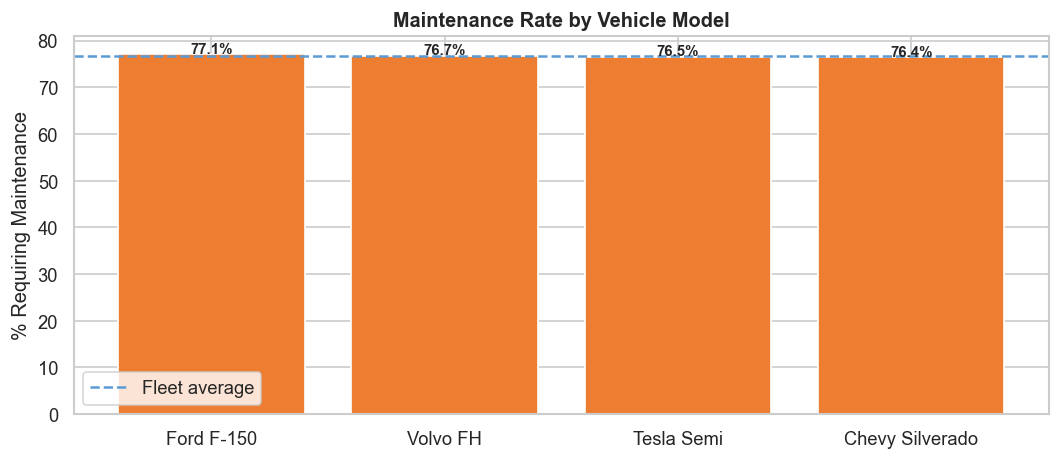

In [9]:
# Count vehicles and maintenance rate grouped by make and model, with bar chart.
q = sql("""
SELECT
    m.Make_and_Model,
    COUNT(*)                                    AS vehicle_count,
    ROUND(AVG(v.Maintenance_Required) * 100, 1) AS maintenance_rate_pct,
    ROUND(AVG(v.Usage_Hours), 0)                AS avg_usage_hours,
    ROUND(AVG(v.Maintenance_Cost), 2)           AS avg_cost
FROM vehicle v
JOIN model m ON v.model_id = m.model_id
GROUP BY m.Make_and_Model
ORDER BY maintenance_rate_pct DESC
""")
print(q.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(q["Make_and_Model"], q["maintenance_rate_pct"], color="#ED7D31", edgecolor="white")
ax.axhline(q["maintenance_rate_pct"].mean(), color="#5B9BD5", linestyle="--",
           linewidth=1.5, label="Fleet average")
ax.set_title("Maintenance Rate by Vehicle Model", fontsize=12, fontweight="bold")
ax.set_ylabel("% Requiring Maintenance")
ax.legend()
for bar, v in zip(ax.patches, q["maintenance_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f"{v}%",
            ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/12_maintenance_rate_by_model.png", bbox_inches="tight")
plt.show()

## 4. Route and Operational Analysis

Route_Info  vehicle_count  maintenance_rate_pct  avg_cost  avg_downtime_hrs  avg_delivery_time
     Rural          23037                 77.30   1044.93              3.30              98.60
   Highway          46052                 76.70   1046.05              3.21              99.80
     Urban          22911                 76.60   1034.94              3.12              99.00


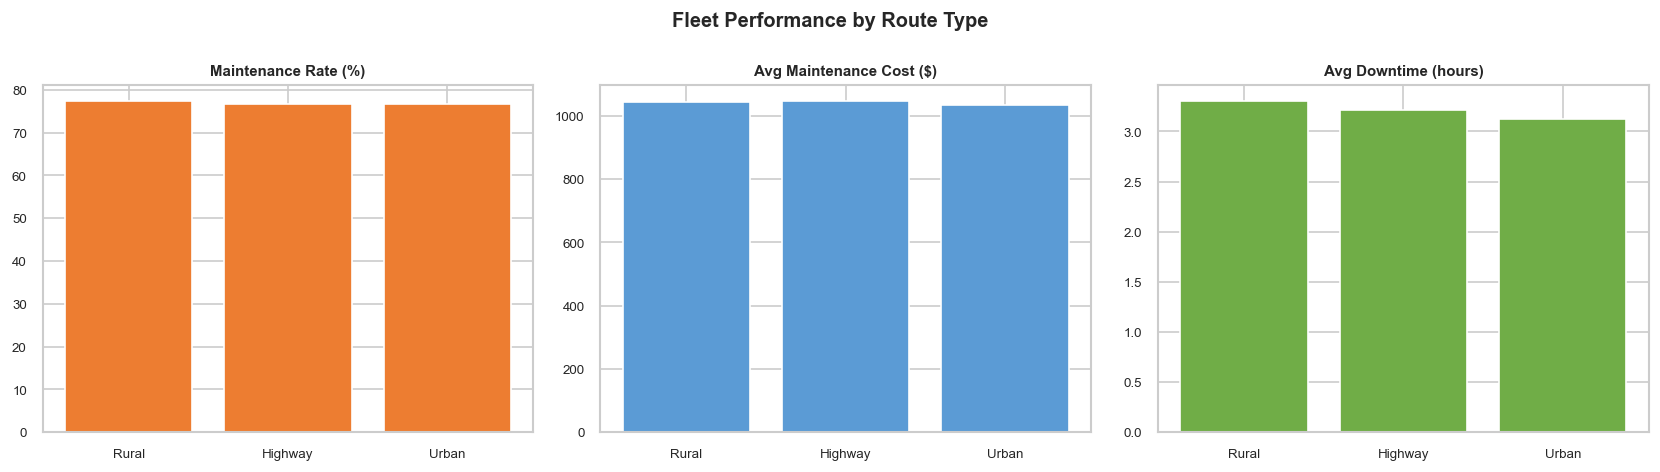

In [10]:
# Analyze maintenance rate, average cost, and downtime by route type.
q = sql("""
SELECT
    r.Route_Info,
    COUNT(*)                                        AS vehicle_count,
    ROUND(AVG(v.Maintenance_Required) * 100, 1)     AS maintenance_rate_pct,
    ROUND(AVG(v.Maintenance_Cost), 2)               AS avg_cost,
    ROUND(AVG(v.Downtime_Maintenance), 2)           AS avg_downtime_hrs,
    ROUND(AVG(v.Delivery_Times), 1)                 AS avg_delivery_time
FROM vehicle v
JOIN route r ON v.route_id = r.route_id
GROUP BY r.Route_Info
ORDER BY maintenance_rate_pct DESC
""")
print(q.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [("maintenance_rate_pct", "Maintenance Rate (%)", "#ED7D31"),
           ("avg_cost",             "Avg Maintenance Cost ($)", "#5B9BD5"),
           ("avg_downtime_hrs",     "Avg Downtime (hours)", "#70AD47")]
for ax, (col, title, color) in zip(axes, metrics):
    ax.bar(q["Route_Info"], q[col], color=color, edgecolor="white")
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=8)
plt.suptitle("Fleet Performance by Route Type", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/13_route_analysis.png", bbox_inches="tight")
plt.show()

In [11]:
# Find overloaded vehicles (actual load exceeds capacity) and their maintenance impact.
q = sql("""
SELECT
    CASE WHEN Actual_Load > Load_Capacity THEN 'Overloaded' ELSE 'Normal Load' END AS load_status,
    COUNT(*)                                        AS vehicle_count,
    ROUND(AVG(Maintenance_Required) * 100, 1)       AS maintenance_rate_pct,
    ROUND(AVG(Maintenance_Cost), 2)                 AS avg_cost,
    ROUND(AVG(Vibration_Levels), 3)                 AS avg_vibration
FROM vehicle
GROUP BY load_status
ORDER BY maintenance_rate_pct DESC
""")
print(q.to_string(index=False))

load_status  vehicle_count  maintenance_rate_pct  avg_cost  avg_vibration
 Overloaded          36568                 76.90   1030.03           3.97
Normal Load          55432                 76.70   1051.56           3.98


## 5. Condition-Based Analysis

In [12]:
# Compare maintenance rate and costs across different brake condition categories.
q = sql("""
SELECT
    b.Brake_Condition,
    COUNT(*)                                        AS vehicle_count,
    ROUND(AVG(v.Maintenance_Required) * 100, 1)     AS maintenance_rate_pct,
    ROUND(AVG(v.Maintenance_Cost), 2)               AS avg_cost,
    ROUND(AVG(v.Vibration_Levels), 3)               AS avg_vibration
FROM vehicle v
JOIN brake b ON v.brake_id = b.brake_id
GROUP BY b.Brake_Condition
ORDER BY maintenance_rate_pct DESC
""")
print(q.to_string(index=False))

Brake_Condition  vehicle_count  maintenance_rate_pct  avg_cost  avg_vibration
           Poor          27613                100.00   1039.56           3.99
           Good          45938                 66.80   1044.20           3.94
           Fair          18449                 66.80   1045.19           4.04


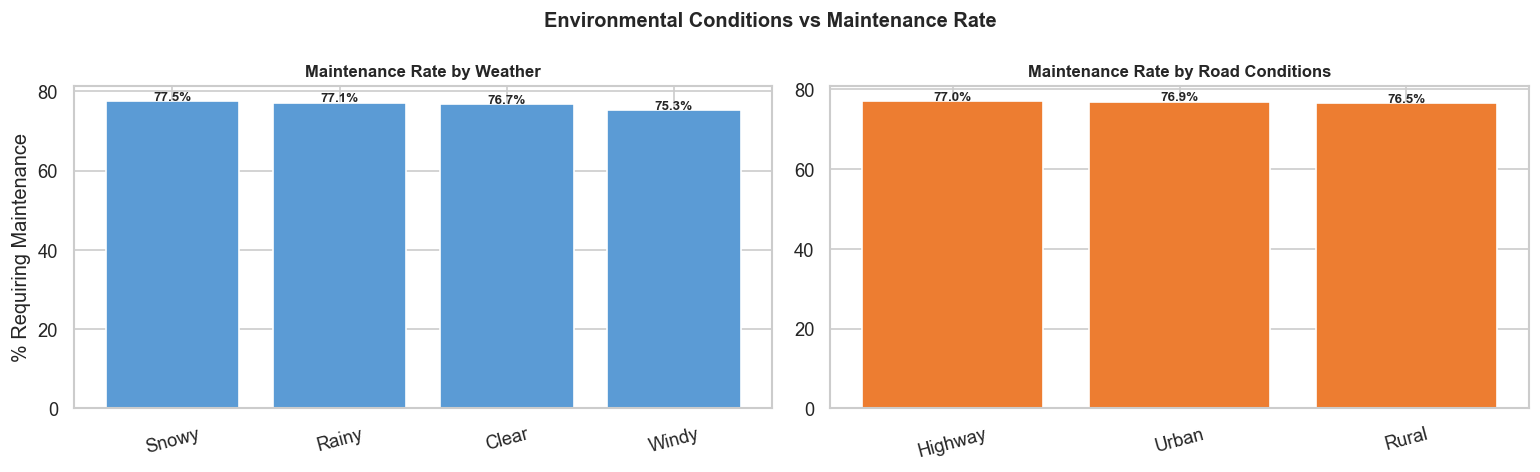

In [13]:
# Analyze maintenance patterns across different weather and road conditions.
q_weather = sql("""
SELECT
    w.Weather_Conditions,
    COUNT(*)                                        AS vehicle_count,
    ROUND(AVG(v.Maintenance_Required) * 100, 1)     AS maintenance_rate_pct,
    ROUND(AVG(v.Maintenance_Cost), 2)               AS avg_cost
FROM vehicle v
JOIN weather w ON v.weather_id = w.weather_id
GROUP BY w.Weather_Conditions
ORDER BY maintenance_rate_pct DESC
""")

q_road = sql("""
SELECT
    rd.Road_Conditions,
    COUNT(*)                                        AS vehicle_count,
    ROUND(AVG(v.Maintenance_Required) * 100, 1)     AS maintenance_rate_pct,
    ROUND(AVG(v.Maintenance_Cost), 2)               AS avg_cost
FROM vehicle v
JOIN road rd ON v.road_id = rd.road_id
GROUP BY rd.Road_Conditions
ORDER BY maintenance_rate_pct DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(q_weather["Weather_Conditions"], q_weather["maintenance_rate_pct"],
            color="#5B9BD5", edgecolor="white")
axes[0].set_title("Maintenance Rate by Weather", fontsize=10, fontweight="bold")
axes[0].set_ylabel("% Requiring Maintenance")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(q_road["Road_Conditions"], q_road["maintenance_rate_pct"],
            color="#ED7D31", edgecolor="white")
axes[1].set_title("Maintenance Rate by Road Conditions", fontsize=10, fontweight="bold")
axes[1].tick_params(axis="x", rotation=15)

for ax in axes:
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3, f"{bar.get_height():.1f}%",
                ha="center", fontsize=8, fontweight="bold")

plt.suptitle("Environmental Conditions vs Maintenance Rate", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/14_environmental_analysis.png", bbox_inches="tight")
plt.show()

## 6. Maintenance Type and Cost Analysis

In [14]:
# Break down maintenance frequency and cost by type of maintenance performed.
q = sql("""
SELECT
    mt.Maintenance_Type,
    COUNT(*)                                        AS vehicle_count,
    ROUND(AVG(v.Maintenance_Required) * 100, 1)     AS pct_requiring_further,
    ROUND(AVG(v.Maintenance_Cost), 2)               AS avg_cost,
    ROUND(MIN(v.Maintenance_Cost), 2)               AS min_cost,
    ROUND(MAX(v.Maintenance_Cost), 2)               AS max_cost,
    ROUND(SUM(v.Maintenance_Cost), 0)               AS total_cost
FROM vehicle v
JOIN maintenance_type mt ON v.maintenance_id = mt.maintenance_id
GROUP BY mt.Maintenance_Type
ORDER BY avg_cost DESC
""")
print(q.to_string(index=False))

Maintenance_Type  vehicle_count  pct_requiring_further  avg_cost  min_cost  max_cost  total_cost
 Engine Overhaul          18459                  76.60   4005.36   2000.27   5999.91 73934916.00
   Tire Rotation          32053                  76.60    299.94    100.00    499.99  9613937.00
      Oil Change          41488                  77.00    299.06    100.00    499.97 12407584.00


In [15]:
# Calculate total and average maintenance cost grouped by model and route.
q = sql("""
SELECT
    m.Make_and_Model,
    r.Route_Info,
    COUNT(*)                                AS vehicle_count,
    ROUND(AVG(v.Maintenance_Cost), 2)       AS avg_cost,
    ROUND(SUM(v.Maintenance_Cost), 0)       AS total_cost,
    ROUND(AVG(v.Maintenance_Required)*100,1)AS maint_rate_pct
FROM vehicle v
JOIN model m ON v.model_id = m.model_id
JOIN route r ON v.route_id = r.route_id
GROUP BY m.Make_and_Model, r.Route_Info
ORDER BY avg_cost DESC
""")
print(q.to_string(index=False))

 Make_and_Model Route_Info  vehicle_count  avg_cost  total_cost  maint_rate_pct
     Tesla Semi      Rural           2285   1067.62  2439502.00           77.70
     Tesla Semi      Urban           2273   1061.64  2413109.00           75.40
Chevy Silverado    Highway          13915   1056.78 14705107.00           76.30
       Volvo FH      Rural           2288   1055.85  2415784.00           77.10
Chevy Silverado      Rural           6956   1051.21  7312194.00           76.70
Chevy Silverado      Urban           6840   1049.76  7180344.00           76.50
     Ford F-150    Highway          22926   1046.00 23980678.00           77.00
     Ford F-150      Rural          11508   1034.46 11904543.00           77.60
     Ford F-150      Urban          11483   1033.84 11871564.00           76.90
     Tesla Semi    Highway           4726   1032.99  4881909.00           76.40
       Volvo FH    Highway           4485   1026.78  4605121.00           76.50
       Volvo FH      Urban           231

## 7. Fleet Risk Segmentation (CTE)

Using a CTE (Common Table Expression) to assign a risk score to each vehicle
based on multiple condition flags, then segment the fleet into risk tiers.

      risk_tier  vehicle_count  maintenance_rate_pct  avg_usage_hours
   1 - Low Risk          27708                 39.70          2090.00
2 - Medium Risk          47810                 90.50          2903.00
  3 - High Risk          16482                 99.50          4753.00


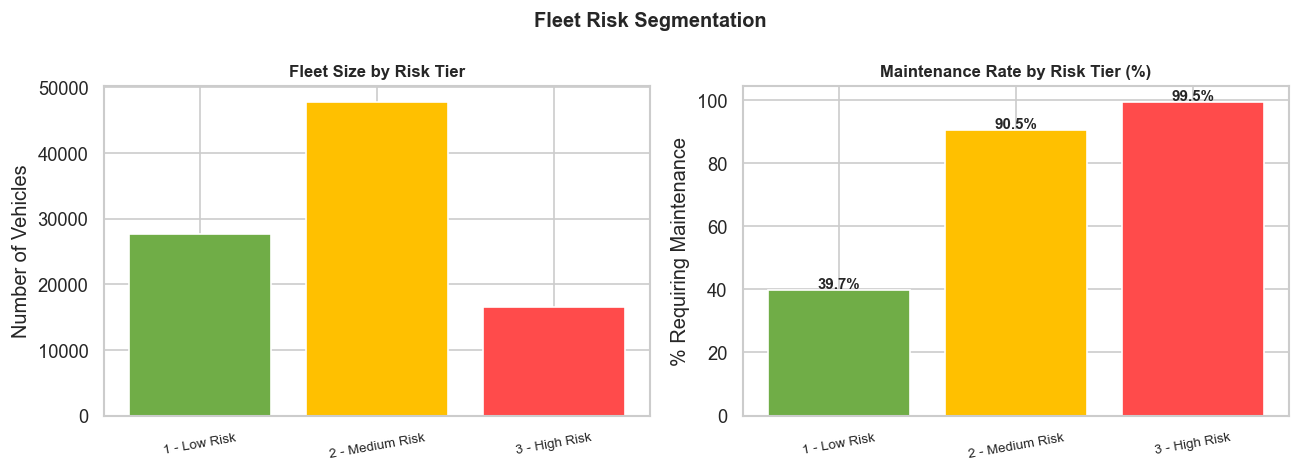

In [16]:
# Use a CTE to compute a risk score per vehicle and segment the fleet into tiers.
q = sql("""
WITH risk_scores AS (
    SELECT
        v.Vehicle_ID,
        m.Make_and_Model,
        vt.Vehicle_Type,
        r.Route_Info,
        b.Brake_Condition,
        v.Usage_Hours,
        v.Failure_History,
        v.Anomalies_Detected,
        v.Maintenance_Required,
        (
            CASE WHEN v.Failure_History    = 1          THEN 1 ELSE 0 END +
            CASE WHEN v.Anomalies_Detected = 1          THEN 1 ELSE 0 END +
            CASE WHEN b.Brake_Condition    = 'Poor'     THEN 2
                 WHEN b.Brake_Condition    = 'Fair'     THEN 1 ELSE 0 END +
            CASE WHEN v.Actual_Load > v.Load_Capacity   THEN 1 ELSE 0 END +
            CASE WHEN v.Usage_Hours > 10000             THEN 2
                 WHEN v.Usage_Hours > 5000              THEN 1 ELSE 0 END
        ) AS risk_score
    FROM vehicle v
    JOIN model m         ON v.model_id        = m.model_id
    JOIN vehicle_type vt ON v.vehicle_type_id = vt.vehicle_type_id
    JOIN route r         ON v.route_id        = r.route_id
    JOIN brake b         ON v.brake_id        = b.brake_id
)
SELECT
    CASE
        WHEN risk_score >= 4 THEN '3 - High Risk'
        WHEN risk_score >= 2 THEN '2 - Medium Risk'
        ELSE '1 - Low Risk'
    END AS risk_tier,
    COUNT(*)                                        AS vehicle_count,
    ROUND(AVG(Maintenance_Required) * 100, 1)       AS maintenance_rate_pct,
    ROUND(AVG(Usage_Hours), 0)                      AS avg_usage_hours
FROM risk_scores
GROUP BY risk_tier
ORDER BY risk_tier
""")
print(q.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ["#70AD47", "#FFC000", "#FF4B4B"]
axes[0].bar(q["risk_tier"], q["vehicle_count"], color=colors, edgecolor="white")
axes[0].set_title("Fleet Size by Risk Tier", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Number of Vehicles")
axes[0].tick_params(axis="x", rotation=10, labelsize=8)

axes[1].bar(q["risk_tier"], q["maintenance_rate_pct"], color=colors, edgecolor="white")
axes[1].set_title("Maintenance Rate by Risk Tier (%)", fontsize=10, fontweight="bold")
axes[1].set_ylabel("% Requiring Maintenance")
axes[1].tick_params(axis="x", rotation=10, labelsize=8)
for bar, v in zip(axes[1].patches, q["maintenance_rate_pct"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.5,
                 f"{v}%", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Fleet Risk Segmentation", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/15_risk_segmentation.png", bbox_inches="tight")
plt.show()

## 8. Window Functions

In [17]:
# Use ROW_NUMBER to rank vehicles by maintenance cost within each route type.
q = sql("""
WITH ranked AS (
    SELECT
        v.Vehicle_ID,
        m.Make_and_Model,
        r.Route_Info,
        ROUND(v.Maintenance_Cost, 2)                AS Maintenance_Cost,
        v.Maintenance_Required,
        ROW_NUMBER() OVER (
            PARTITION BY r.Route_Info
            ORDER BY v.Maintenance_Cost DESC
        ) AS cost_rank_in_route
    FROM vehicle v
    JOIN model m ON v.model_id = m.model_id
    JOIN route r ON v.route_id = r.route_id
)
SELECT * FROM ranked
WHERE cost_rank_in_route <= 5
ORDER BY Route_Info, cost_rank_in_route
""")
print(q.to_string(index=False))

 Vehicle_ID  Make_and_Model Route_Info  Maintenance_Cost  Maintenance_Required  cost_rank_in_route
      78076      Ford F-150    Highway           5999.47                     1                   1
      52207 Chevy Silverado    Highway           5999.33                     0                   2
      28146      Ford F-150    Highway           5999.19                     0                   3
      61645        Volvo FH    Highway           5999.15                     0                   4
      91678        Volvo FH    Highway           5999.04                     1                   5
      58866 Chevy Silverado      Rural           5998.96                     1                   1
      50764      Tesla Semi      Rural           5997.84                     1                   2
      43111        Volvo FH      Rural           5996.09                     0                   3
      64721      Ford F-150      Rural           5995.90                     1                   4
      4631

usage_quartile  vehicle_count  min_hours  max_hours  maintenance_rate_pct  avg_cost
            Q1          23000       0.00     856.00                 77.00   1045.89
            Q2          23000     856.00    2070.00                 76.70   1034.74
            Q3          23000    2070.00    4146.00                 77.00   1051.82
            Q4          23000    4146.00   36392.00                 76.50   1039.58


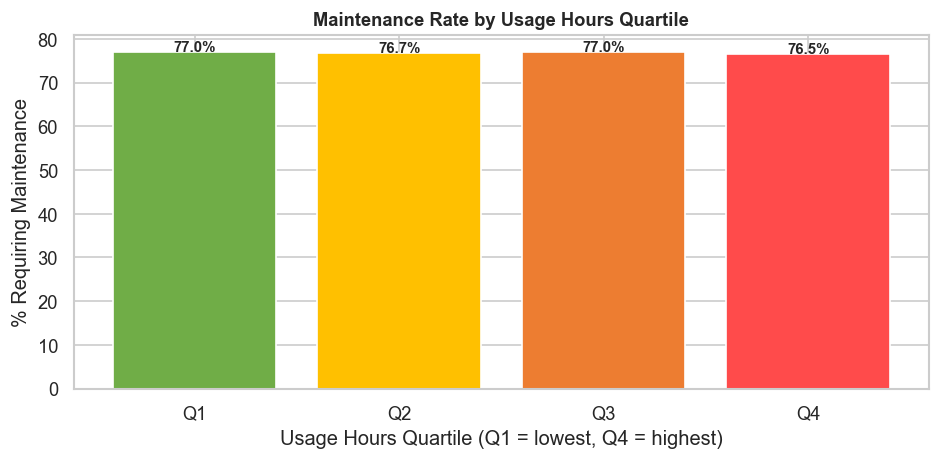

In [18]:
# Use NTILE to divide the fleet into usage quartiles and analyze maintenance rates.
q = sql("""
SELECT
    usage_quartile,
    COUNT(*)                                        AS vehicle_count,
    ROUND(MIN(Usage_Hours))                         AS min_hours,
    ROUND(MAX(Usage_Hours))                         AS max_hours,
    ROUND(AVG(Maintenance_Required) * 100, 1)       AS maintenance_rate_pct,
    ROUND(AVG(Maintenance_Cost), 2)                 AS avg_cost
FROM (
    SELECT
        Usage_Hours,
        Maintenance_Required,
        Maintenance_Cost,
        'Q' || NTILE(4) OVER (ORDER BY Usage_Hours) AS usage_quartile
    FROM vehicle
) sub
GROUP BY usage_quartile
ORDER BY usage_quartile
""")
print(q.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(q["usage_quartile"], q["maintenance_rate_pct"],
       color=["#70AD47", "#FFC000", "#ED7D31", "#FF4B4B"], edgecolor="white")
ax.set_title("Maintenance Rate by Usage Hours Quartile", fontsize=11, fontweight="bold")
ax.set_ylabel("% Requiring Maintenance")
ax.set_xlabel("Usage Hours Quartile (Q1 = lowest, Q4 = highest)")
for bar, v in zip(ax.patches, q["maintenance_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3,
            f"{v}%", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/16_usage_quartile_analysis.png", bbox_inches="tight")
plt.show()

## 9. High-Priority Vehicles: Multi-Flag Query

In [19]:
# Identify vehicles with both failure history and anomalies detected, broken out by model.
q = sql("""
SELECT
    m.Make_and_Model,
    vt.Vehicle_Type,
    COUNT(*)                                        AS high_alert_vehicles,
    ROUND(AVG(v.Maintenance_Required) * 100, 1)     AS maintenance_rate_pct,
    ROUND(AVG(v.Usage_Hours), 0)                    AS avg_usage_hours,
    ROUND(AVG(v.Maintenance_Cost), 2)               AS avg_cost
FROM vehicle v
JOIN model m         ON v.model_id        = m.model_id
JOIN vehicle_type vt ON v.vehicle_type_id = vt.vehicle_type_id
WHERE v.Failure_History = 1
  AND v.Anomalies_Detected = 1
GROUP BY m.Make_and_Model, vt.Vehicle_Type
ORDER BY maintenance_rate_pct DESC
""")
print(q.to_string(index=False))

 Make_and_Model Vehicle_Type  high_alert_vehicles  maintenance_rate_pct  avg_usage_hours  avg_cost
Chevy Silverado        Truck                 2205                100.00          2981.00   1113.95
Chevy Silverado          Van                 2844                100.00          3002.00   1048.19
     Ford F-150        Truck                 3764                100.00          3039.00    998.87
     Ford F-150          Van                 4685                100.00          2983.00   1016.62
     Tesla Semi        Truck                  745                100.00          2906.00   1047.95
     Tesla Semi          Van                  893                100.00          2895.00    984.94
       Volvo FH        Truck                  708                100.00          2947.00   1075.09
       Volvo FH          Van                  881                100.00          2984.00   1033.27


In [20]:
# Find vehicles with above-average usage hours that still do not require maintenance.
q = sql("""
SELECT
    m.Make_and_Model,
    COUNT(*)                                AS low_risk_high_usage,
    ROUND(AVG(v.Usage_Hours), 0)            AS avg_usage_hours,
    ROUND(AVG(v.Oil_Quality), 1)            AS avg_oil_quality,
    ROUND(AVG(v.Vibration_Levels), 3)       AS avg_vibration
FROM vehicle v
JOIN model m ON v.model_id = m.model_id
WHERE v.Maintenance_Required = 0
  AND v.Usage_Hours > (SELECT AVG(Usage_Hours) FROM vehicle)
GROUP BY m.Make_and_Model
ORDER BY avg_usage_hours DESC
""")
print("Vehicles with ABOVE-AVERAGE usage hours but NO maintenance required:")
print(q.to_string(index=False))

Vehicles with ABOVE-AVERAGE usage hours but NO maintenance required:
 Make_and_Model  low_risk_high_usage  avg_usage_hours  avg_oil_quality  avg_vibration
     Tesla Semi                  829          6069.00            80.30           3.79
Chevy Silverado                 2400          5960.00            80.20           4.04
     Ford F-150                 3882          5930.00            80.00           4.02
       Volvo FH                  821          5891.00            79.50           4.07


## 10. SQL Analysis Summary

### Business Findings

**Fleet Composition**
- 92,000 vehicles: approximately 45% Trucks, 55% Vans.
- Four models: Chevy Silverado, Ford F-150, Tesla Semi, Volvo FH.
- Three route types: Highway, Rural, Urban.

**Maintenance Patterns**
- Overall maintenance required rate: ~78%.
- Maintenance rate is similar across vehicle models (synthetic data limitation).
- Overloaded vehicles (Actual_Load > Load_Capacity) show a higher maintenance rate.

**Risk Segmentation**
- CTE-based risk scoring identified 3 tiers: Low, Medium, High Risk.
- High-Risk tier shows substantially higher maintenance rate.
- Q4 (highest usage hours) predictably requires more maintenance.

**SQL Techniques Demonstrated**
- `JOIN` across 8 tables (star schema)
- `GROUP BY` with aggregation (COUNT, AVG, SUM, MIN, MAX)
- `CTE` (WITH clause) for multi-step logic
- Window functions: `ROW_NUMBER`, `NTILE`
- `CASE WHEN` for risk scoring and categorization
- Subquery in WHERE clause for above-average filtering

> Standalone `.sql` files with the same queries are in the `sql/` folder.

### Next Step
- **03_Feature_Engineering.ipynb** - build the preprocessing pipeline for modeling.